## Demonstration

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1xvvijPv4sv3aBJvFYD--1RdrQACcsNDS?usp=sharing)

## 1. The International Image Interoperability Framework (IIIF) Manifest
### Find a IIIF manifest in EAP

Most collections in the Endangered Archives Programme are published online. This allows you to view the scanned materials on the British Library's site.

It is also possible to access these collections as data. The BL provides access to both metadata and images using the International Image Interoperability Framework (IIIF).


1. Go to https://eap.bl.uk/search
2. Click on "View archives from this project." If you don't see that button, the images are not available yet on the EAP site.
3. Find a File that interests you.
4. Locate the IIIF icon (![](https://eap.bl.uk/modules/custom/cogapp_collection_pages/images/logo_iiif.png)) and get the link. You can click on the icon and select the address. You can also right-click on the icon and select "copy link".
5. You should get something that looks like the manifest URL below.





In [2]:
manifest_url = "https://eap.bl.uk/archive-file/EAP1299-2-13-5/manifest?manifest=https%3A//eap.bl.uk/archive-file/EAP1299-2-13-5/manifest" # @param {"type":"string"}
# Note that the manifest URL needs to be in quotes


> Some manifests always return a 202 error. We're not sure why. If that happens. Open the manifest URL in your browser. Save it as manifest.json.  Then upload the file by clicking the Files icon to the left and then "Upload to session storage." Then change the manifest url above to `manifest.json` and try again.

Beyond serving images and metadata to the Web, the IIIF also allows for many transformations of the image just by changing the URL. You can request a black and white version, a cropped version, or a resized version. See the [IIIF Image API documentation](https://iiif.io/api/image/3.0/) for more details.



# Download images for processing

In [86]:
# needed to run async in Jupyter

import nest_asyncio
nest_asyncio.apply()

### Sample size
At first, we'll only process a few files. However, you can change this setting to process entire collections.  
For demonstration purposes, we only download the first ten images. To download all images, change to None.


In [ ]:
sample_size = 10

# Evaluate the images

Before moving forward, it is helpful to manually inspect a few of the images. Could you transcribe the text given the image? As a general rule of thumb, if you're not able to complete the task manually, the model won't be able to either.




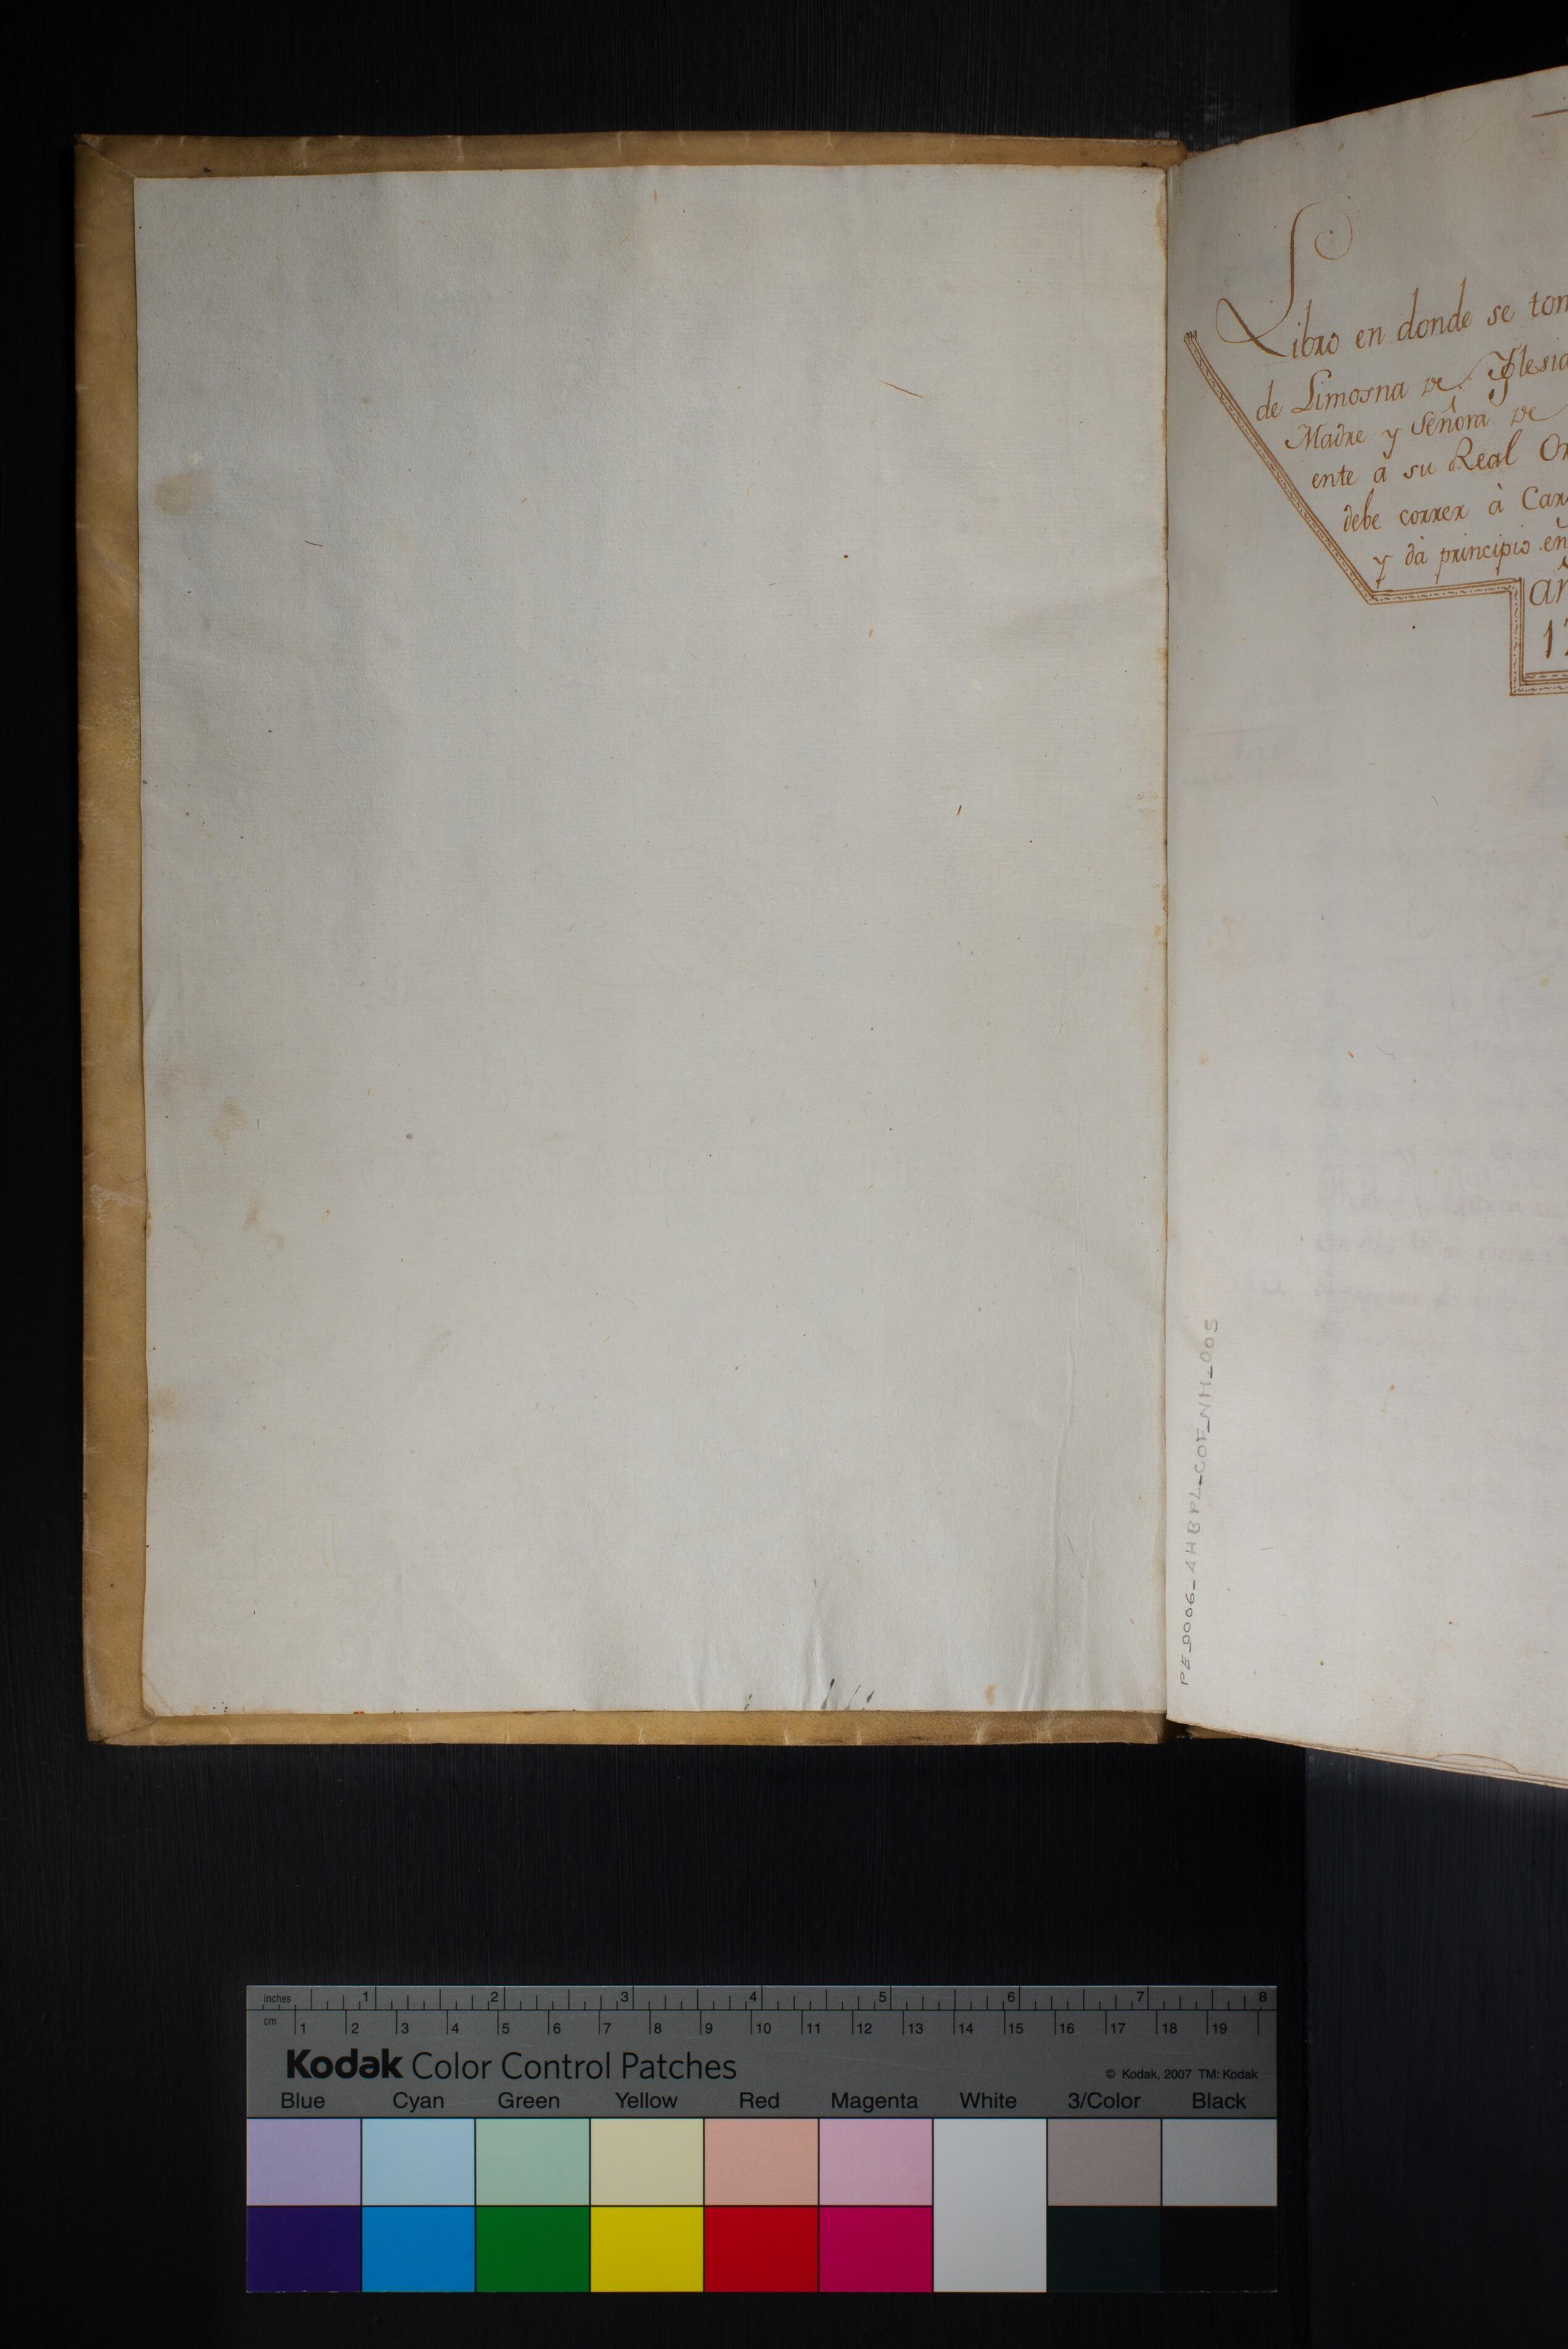

In [ ]:
# Inspect a random page from the downloaded images
import random
from PIL import Image
import os

img_folder = "img"
img_files = [f for f in os.listdir(img_folder) if f.lower().endswith((".png", ".jpg"))]
random_img_file = random.choice(img_files)
img_path = os.path.join(img_folder, random_img_file)
img = Image.open(img_path)
img

## Connect to Google Drive

We're now going to create a folder in Drive. Feel free to change the name if you like.  The main goal is to create a folder of images that we can access in the next section.

> Start here if you're only working with a folder on Drive and not from a IIIF collection.


In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import os

source_dir = '/content/img'
destination_folder_name = "EAP550-1-3"
destination_dir = f'/content/drive/MyDrive/{destination_folder_name}'

os.makedirs(destination_dir, exist_ok=True)

for item in os.listdir(source_dir):
    s = os.path.join(source_dir, item)
    d = os.path.join(destination_dir, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, symlinks=False, ignore=None)
    else:
        shutil.copy2(s, d)
print(f"Contents of {source_dir} copied to {destination_dir}")

Contents of /content/img copied to /content/drive/MyDrive/fantastic_futures_img

# Using your own images

Very often, researchers work with materials from several archives and collections. It's also very common to take photos with your phone in the archives.

If you have these kinds of images, you can add them to your folder in Drive.

The next two cells will covert any PDF files or .HEIC files (iPhone) into jpegs for processing.

In [96]:
%pip install -q pymupdf

In [ ]:
import pymupdf
from pathlib import Path
from tqdm import tqdm

drive_pdfs = Path(destination_dir).glob('**/*.pdf')
for pdf_file in drive_pdfs:
  doc = pymupdf.open(pdf_file)
  for i, page in tqdm(enumerate(doc)):  # iterate through the pages
      pix = page.get_pixmap(dpi=150)
      img = pix.pil_image()
      img.save(f"{pdf_file.parent}/{pdf_file.stem}_{i}.jpg")

87it [00:30,  2.84it/s]


In [98]:
%pip install -q pillow-heif

In [ ]:
from PIL import Image
from pillow_heif import register_heif_opener

# Register the HEIF opener
register_heif_opener()

drive_heic = Path(destination_dir).glob('**/*.HEIC')

for heic_file in tqdm(drive_heic):
  img = Image.open(heic_file)
  img.save(f"{heic_file.parent}/{heic_file.stem}.jpg")

1it [00:01,  1.92s/it]


# 2. Processing Workflow to Extract Text and Metadata

While the descriptions from the first notebook are nice, they're not research data or archival metadata.

This next section details a workflow that will process your materials into a structured format that can be used for research or library systems. This is an example that can be adapted to your specific needs.



### Vision-Language Models

This workshop features a relatively new kind of machine learning model. Traditional optical character recognition (OCR) models look for patterns in an image and map them to machine-readable characters. The process is entirely visual. Recent advances in large language models provide a general understanding of natural language.  Vision-language models add a visual component to the language model. As a result, the model's predictions are informed by the visual features of the handwritten text image as well as the model's knowledge of language. This combination leads to much improved accuracy with text extraction from handwritten documents.

We should note that VLMs also "hallucinate." They will guess even when they're not sure.  In some cases, they will "improve" on your original document by correcting spelling or word choice.  While we cannot use these models uncritically, they very often move us from "could this better?" to "good enough."

> Why not use ChatGPT or Claude?  
> While proprietary frontier models are powerful, they can be very expensive to use at scale. Using open models like Qwen allows you to have more control over costs and data privacy. Additionally, we're using a smaller model (8 billion parameters versus 1 trillion) that is focused on a specific task.

In [100]:
!pip install -q langchain==0.3.27 langchain-core==0.3.79 langgraph nest-asyncio

# Sending your files to the model

Before we can send your files to the model, we first need to encode them.

The most common way to do this is to encode the binary data in your file as a string of characters using the base64 encoding system.  So rather than sending ones and zeros over the Internet, we'll be sending packets of text characters.  On the other end, the model turns that data back into an image file to process.

In [101]:
# @title Encode images for transfer over the Internet
import base64
from pathlib import Path

def encode_images(image_directory: str, file_extensions: list = ['.jpg', '.png'], data_uri: bool = True):
    """Generator to encode images in the specified directory to base64 strings.

    Args:
        image_directory (Path): The directory containing images to encode.
        file_extensions (list, optional): List of file extensions to consider. Defaults to ['.jpg', '.png'].
        data_uri (bool, optional): If True, includes the data URI scheme in the output. Defaults to True.

    Yields:
        str: Base64 encoded string of each image.
    """
    image_directory = Path(image_directory)
    if not image_directory.is_dir():
        raise ValueError(f"The provided path {image_directory} is not a valid directory.")
    image_paths = [p for p in image_directory.iterdir() if p.suffix.lower() in file_extensions]
    for path in image_paths:
        with open(path, 'rb') as img_file:
            encoded_string = base64.b64encode(img_file.read()).decode('utf-8')
            if data_uri:
                mime_type = 'image/jpeg' if path.suffix.lower() == '.jpg' else 'image/png'
                yield path, f"data:{mime_type};base64,{encoded_string}"
            else:
                yield path, encoded_string




# Add the API Key
For this workshop, we'll provide a key that you can use to connect with Alibaba's servers in Singapore. The model that we're using is open-source and can be run locally or on high performance computing.

To add the API key,
- click on the key icon to the left.
- Add new secret.
- Under name enter: DASHSCOPE_API_KEY
- Under Value enter:

Please note that the key will not work after the workshop. You are welcome to get a key yourself or connect with any of the other providers listed [here](https://openrouter.ai/qwen/qwen3-vl-8b-instruct/providers).
To create a key with Alibaba:
- [Create an Alibaba Cloud account](https://account.alibabacloud.com/register/intl_register.htm)
- [Create an API key](https://www.alibabacloud.com/help/en/model-studio/get-api-key)

In [102]:
from google.colab import userdata

base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1"
api_key= userdata.get('DASHSCOPE_API_KEY') # We will provide you with an API key for the workshop

While we're using Alibaba for the workshop, we are deliberately model and provider agnostic.  

Hugging Face 🤗
```python
base_url="https://router.huggingface.co/v1"
api_key=userdata.get('HF_TOKEN')
model="Qwen/Qwen3-VL-30B-A3B-Instruct:novita"
```
OpenAI
 ```python 
 base_url="https://api.openai.com/v1"
 api_key=userdata.get('OPENAI_API_KEY')
 model = 'gpt-5-mini'
 ```
Anthropic 
 ```python
 base_url="https://api.anthropic.com/v1"
 api_key=userdata.get('ANTHROPIC_API_KEY')
 model = 'claude-sonnet-4-20250514'
 ```


# State

As we move from step to step in the workflow, we will need something to store the data from prior steps and to make that data available. This object is often called "state" in programming. In the cell below, we create a simple state object to hold our data as we move through the workflow.

Given that we're processing a box of archival materials, I have called it "Box." I find it helpful to think of the fields in the object as columns in a spreadsheet. Each field (box_manifest_uri, image_uris...) gives us a placeholder for information that we'd like to gather during the workflow. How you design your state object can be helpful in deciding what steps are needed in the workflow and what your final output should look like.

In [3]:
# https://langchain-ai.github.io/langgraph/tutorials/workflows/#prompt-chaining
# https://typing.python.org/en/latest/spec/typeddict.html

from typing_extensions import TypedDict

class Box(TypedDict):  # Level: File in EAP
    image_path: str
    box_metadata: dict
    file_lookup: dict
    images: list[dict]


# Steps in the Workflow

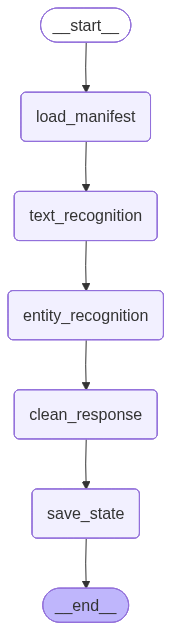

In [ ]:
Chart of the workflow:

In [7]:
from langgraph.graph import StateGraph, START, END


# Build workflow
builder = StateGraph(Box)

# Add nodes
builder.add_node("load_manifest", load_manifest)
builder.add_node("text_recognition", text_recognition)
builder.add_node("entity_recognition", entity_recognition)
builder.add_node("clean_response", clean_response)
builder.add_node("save_state", save_state)

# Add edges to connect nodes
builder.add_edge(START, "load_manifest")
builder.add_edge("load_manifest", "text_recognition")
builder.add_edge("text_recognition", "entity_recognition")
builder.add_edge("entity_recognition", "clean_response")
builder.add_edge("clean_response", "save_state")
builder.add_edge("save_state", END)

# Compile
graph = builder.compile()

In [ ]:
# Invoke

output = graph.invoke({"image_path":destination_dir})

In [ ]:
# inspect results
import random
from IPython.display import Image

images = output.get('images')
image = random.choice(images)

print(image)
Image(url=image["image_uri"], width=400)


# 3. Saving and Publishing

Now that you've run the workflow in the previous notebook, it's time to turn that data into something familiar that you can use. In this section, we'll turn the output JSON file into a spreadsheet and a static website.  

## Create a spreadsheet


In [ ]:
import shutil
from pathlib import Path

output_path = '/content/output'
data_files = Path(output_path).glob("*.json")
data_files = list(data_files)
print(f"Found {len(data_files)} file(s)")

In [ ]:
# name, image_uri, cleaned_text, box_metadata>"Idenfifier"
import srsly
from csv import DictWriter


def output_json_to_spreadsheet(data_files: list):
  rows = []
  for data_file in data_files:
    data = srsly.read_json(data_file)
    box_identifier = data.get('box_metadata', 'unlabeled_box').get('Identifier','')
    images = data.get('images',[])
    # sort the images by filename
    images = sorted(images, key=lambda x: x.get('name',''))
    for image in images:
      rows.append({
          'name': image.get('name',''),
          'image_uri': image.get('image_uri',''),
          'cleaned_text': image.get('cleaned_text',''),
          'box_identifier': box_identifier
      })
  writer = DictWriter(open(data_file.with_suffix('.csv'),'w'), fieldnames=rows[0].keys())
  writer.writeheader()
  writer.writerows(rows)

output_json_to_spreadsheet(data_files)

Save the output.csv file to Drive

In [ ]:
# sync content in folders
import shutil

source_dir = '/content/output'
destination_dir = f"/content/drive/MyDrive/{destination_folder_name}/output/"

shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)

With the file saved, you can now go to Drive to work with your data.
- In your folder, you'll find an `output` subfolder
- click to open the `output.csv` file
- Then click on "Open in Google Sheets" (center top of the page)

## Create a static website

In [ ]:
import srsly
import markdown
from pathlib import Path

if not Path('_site').exists():
  Path('_site').mkdir()

for data_file in data_files:
    data = srsly.read_json(data_file)
    images = data.get('images',[])
    images = sorted(images, key=lambda x: x.get('name',''))
    first_image = images[0]['name'] + ".html"
    last_image = images[-1]['name'] + ".html"
    for idx, image in enumerate(images):
        next_image = images[idx+1]['name'] + ".html" if idx < len(images)-1 else first_image
        prev_image = images[idx-1]['name'] + ".html" if idx > 0 else last_image
        cleaned_text = image.get('cleaned_text','')
        cleaned_text = markdown.markdown(cleaned_text, extensions=['tables'])
        sort_value = int("".join([char for char in image["name"] if char.isdigit()]))
        html_template = f"""
        <!DOCTYPE html>
        <html>
          <body>
            <button><a href="/">Back to Search</a></button>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
            <button><a href="{prev_image}">Back</a></button>
            <button><a href="{next_image}">Forward</a></button>

            <h1 data-pagefind-sort="page:{sort_value}">{image["name"]}</h1>
            <img src="{image["image_uri"]}">
            <p>{cleaned_text}</p>
            <table>
              <tr>
                <th>Entity</th>
                <th>Type</th>
                <th>Context</th>
              </tr>
              {[f"<tr><td>{entity["entity"]}</td><td>{entity["type"]}</td><td>{entity["context"]}</td></tr>" for entity in image["entities"] if isinstance(entity, dict) and entity.get('entity',None) and entity.get('type',None) and entity.get('context', None)]}
            </table>
          </body>
        </html>
        """
        Path(f"_site/{image['name']}.html").write_text(html_template)

In [ ]:
full_metadata_html = ""
for data_file in data_files:
    data = srsly.read_json(data_file)
    box_metadata = data.get('box_metadata',{})
    identifier = box_metadata.get('Identifier','no_identifier')
    full_metadata_html += f"<h1>{identifier}</h1>"
    for key, value in box_metadata.items():
      full_metadata_html += f"<h2>{key}</h2>"
      full_metadata_html += f"<p>{value}</p><br>"
    full_metadata_html += "<hr>"

index = f"""

<!DOCTYPE html>
        <html>
          <head>
          <link href="/pagefind/pagefind-ui.css" rel="stylesheet">
          <script src="/pagefind/pagefind-ui.js"></script>
          </head>
          <body>
            <div id="search"></div>
            {full_metadata_html}"""
index += """
            <script>
                window.addEventListener('DOMContentLoaded', (event) => {
                    new PagefindUI({
                      element: "#search",
                      sort: { date: "desc" },
                      showSubResults: true
                    });

                });
            </script>
             </body>
        </html>
"""
Path('_site/index.html').write_text(index)

Create a search index

In [ ]:
%pip install -q 'pagefind[extended]'

In [ ]:
!python3 -m pagefind --site _site

In [ ]:
import shutil
zip_file = shutil.make_archive('site', 'zip', '/content/_site')

In [ ]:
# Save the zip file to Drive
import shutil

source_file = '/content/site.zip'
destination_dir = f"/content/drive/MyDrive/{destination_folder_name}/output/"

shutil.copy(source_file, destination_dir)

In [ ]:
from google.colab import files
files.download(zip_file)

## Open the website on your computer

You can then unzip the `site.zip` file on your computer and view it in your web browser.

- Open your terminal application
- Navigate to the unzipped folder (ex. `cd ~/Downloads/site`)
- Enter this command `python -m http.server` and press enter.
- The site should now be visible in the browser at http://0.0.0.0:8000/


## Deploy your website to the web

There are many ways to put your site up on the web.  One of the simplest is a company called Netlify, which has a nice free tier.

- Create an account with Netlify: https://app.netlify.com/signup
- Login in to the new account
- Select the Projects tab on the left
- Then select Add New Project
- In the dropdown, select Deploy Manually
- Drag and drop the unzipped `site` folder from your computer
- Once uploaded, you should see a URL for your site. Something like `33242-fish-pickle.netlify.app`
- You can change the web address in General > Project Details > Change Project Name
- For example, I changed the address to: https://eap617-1-10.netlify.app


## Collaborations with Libraries, Archives and Museums

While it's great to have a spreadsheet or static page to work from, ideally we'll find ways for transcriptions and data to find their way back to the British Library and other libraries and museums. Librarians and archivists are hard at work developing this capability.  For example, the Swedish National Archives, recently added the ability to search over 3 million hand-written documents.  

- [Here is a post about this work (in Swedish and English)](https://riksarkivet.se/inlagg/riksarkivet-gor-en-miljon-handskrivna-dokument-sokbara)
- [Here is an example search result](https://sok.riksarkivet.se/bildvisning/A0065892_00072#?q=blau&xywh=-957%2C0%2C7736%2C4863&hi=3&cv=71)

--- 

Disclosure of Delegation to Generative AI

The authors declare the use of generative AI in the research and writing process. According to the [GAIDeT taxonomy (2025)](https://panbibliotekar.github.io/gaidet-declaration/), the following tasks were delegated to GAI tools under full human supervision:

- Code generation
- Code optimization

The GAI tool used was: Claude Sonnet 4.5.  
Responsibility for the final manuscript lies entirely with the authors.
GAI tools are not listed as authors and do not bear responsibility for the final outcomes.
Declaration submitted by: Andy Janco